In [1]:
from utils import *

import torch as th
import torch.nn as nn
import torch.nn.utils.prune as prune
import torch.nn.functional as F

import importlib
import data_handler

importlib.reload(data_handler)

import tqdm


In [2]:
import torch
import torch.nn as nn
import torchvision.models as models

class RNet(nn.Module):
    def __init__(self, num_classes=2):
        super(RNet, self).__init__()
        self.resnet = models.resnet18(pretrained=False)
        
        in_features = self.resnet.fc.in_features
        #self.resnet.fc = nn.Linear(in_features, num_classes)
        
        
        self.resnet.fc = nn.Sequential(
            nn.Linear(in_features, 4096), 
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, num_classes)
            )

    def forward(self, x):
        return self.resnet(x)

# Example usage:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RNet(num_classes=2).to(device)
print(model)


c:\Users\Danie\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Danie\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


RNet(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running

In [103]:
device = th.device("cuda" if th.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = RNet().to(device)


def train():
    """
    """
    # params
    epochs = 10
    lr = 0.0001
    # Loss function
    #loss_func = nn.BCEWithLogitsLoss()
    loss_func = nn.CrossEntropyLoss()

    # Optimizer and model inits
    optimizer = th.optim.Adam(model.parameters(), lr=lr)
    model.train()
    for epoch in tqdm.tqdm(range(epochs)):
        for images, labels in data_handler.tr_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)

            # Calculate the loss
            loss = loss_func(outputs, labels)

            # Backward pass and gradient update
            loss.backward()
            optimizer.step()
            
            torch.cuda.empty_cache()

            
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item()}")
    
    th.save(model.state_dict(), "resnet18_not_pretrained_with_dropout.pt")

Device: cuda


In [104]:
train()

 10%|█         | 1/10 [00:04<00:44,  4.94s/it]

Epoch 1/10, Loss: 0.8555906414985657


 20%|██        | 2/10 [00:09<00:38,  4.78s/it]

Epoch 2/10, Loss: 0.6859244704246521


 30%|███       | 3/10 [00:14<00:32,  4.71s/it]

...

Epoch 8/10, Loss: 1.6099309921264648


 90%|█████████ | 9/10 [00:42<00:04,  4.74s/it]

Epoch 9/10, Loss: 0.004532774910330772


100%|██████████| 10/10 [00:47<00:00,  4.75s/it]

Epoch 10/10, Loss: 0.0005532155628316104


C:\Users\Danie\AppData\Local\Temp\ipykernel_18816\1660490038.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(th.load("resnet18_not_pretrained_with_

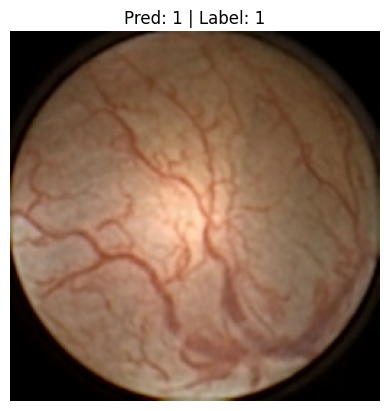

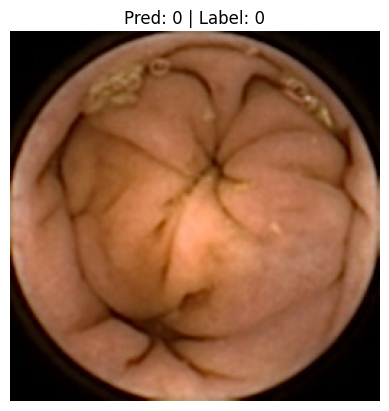

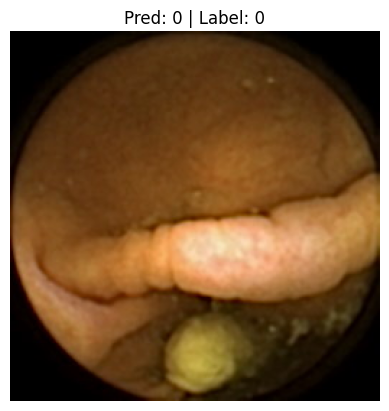

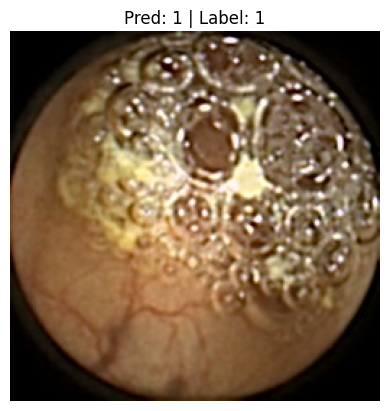

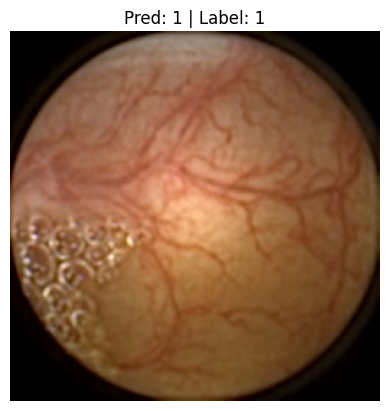

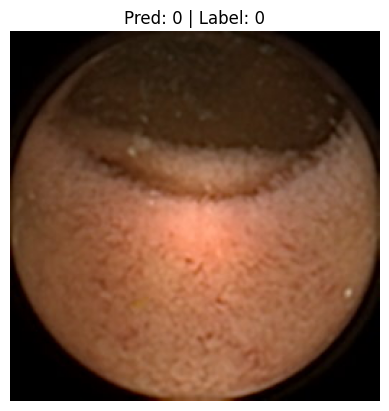

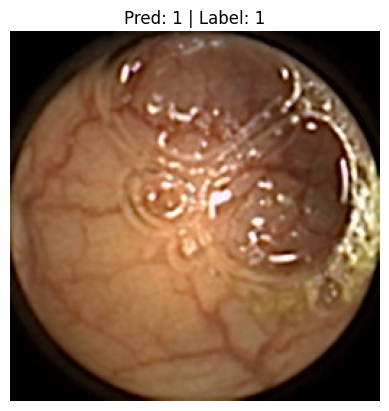

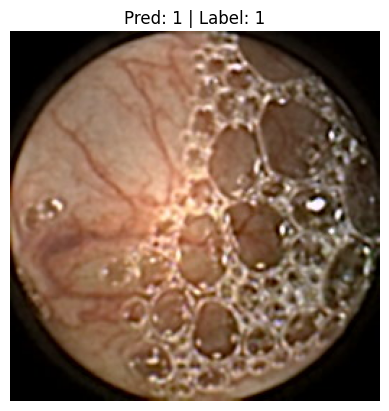

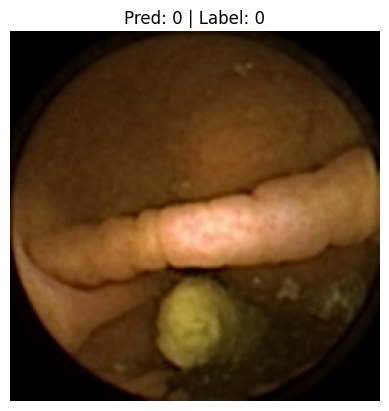

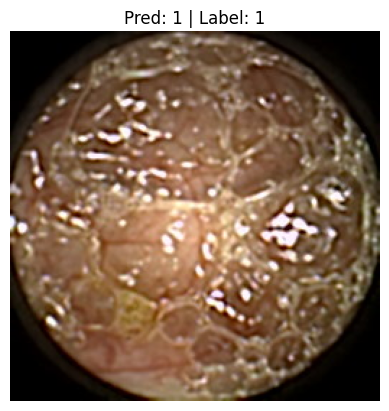

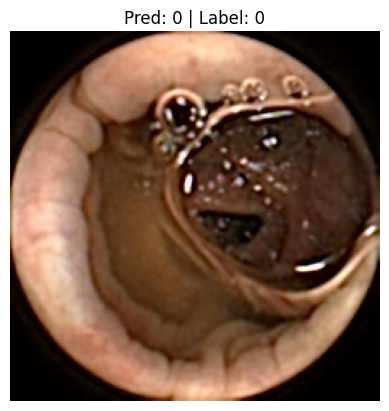

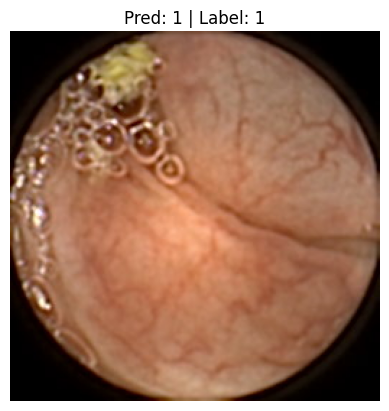

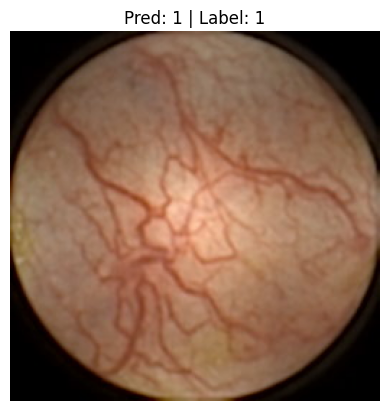

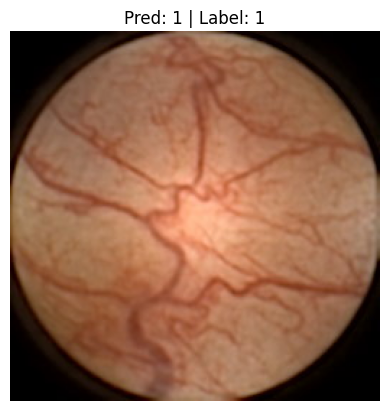

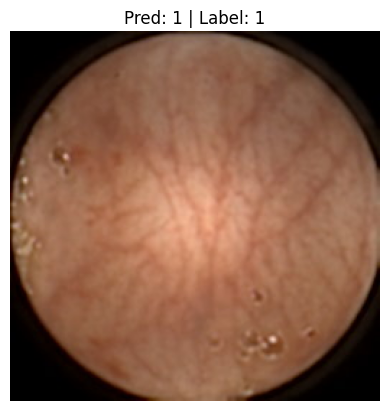

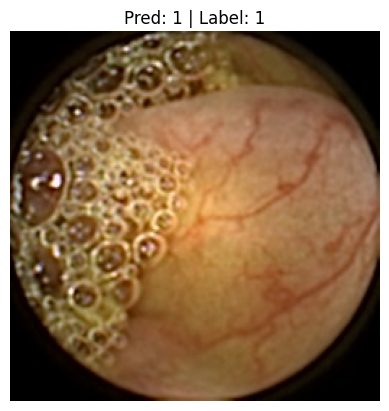

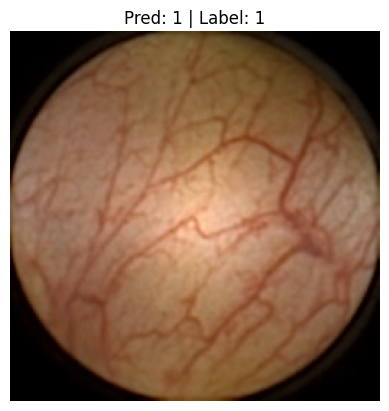

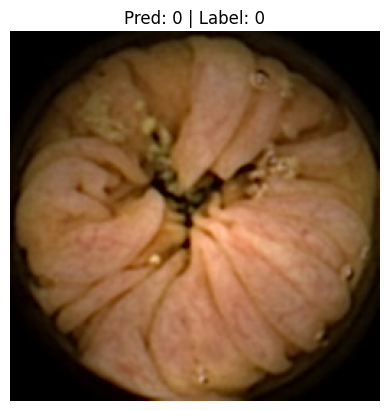

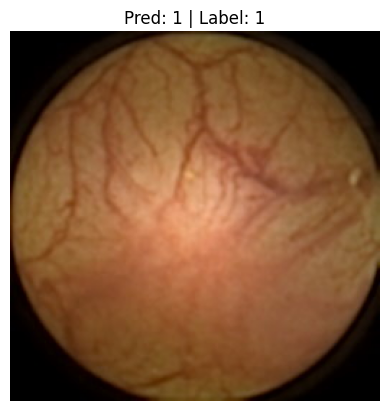

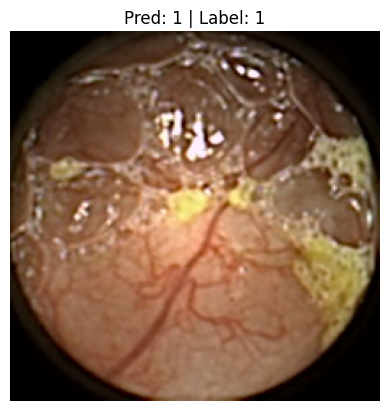

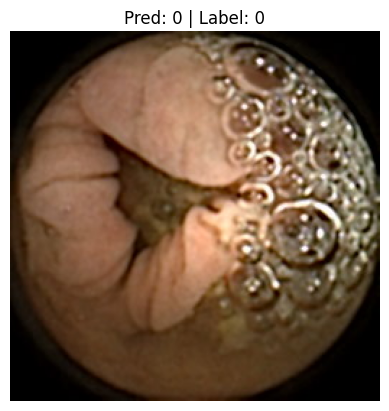

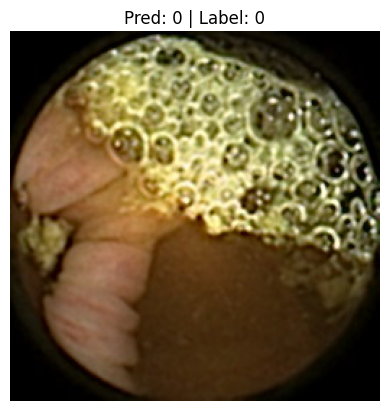

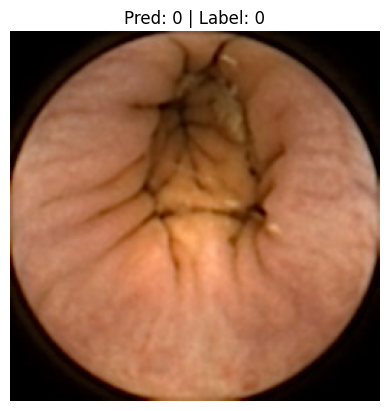

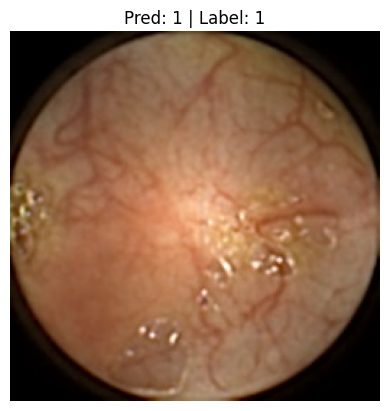

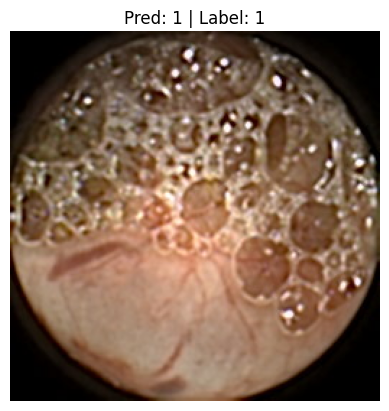

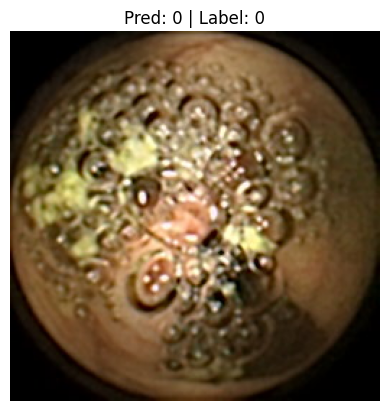

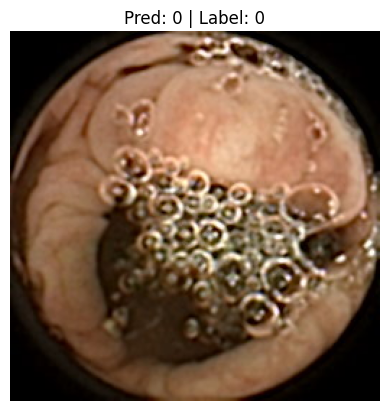

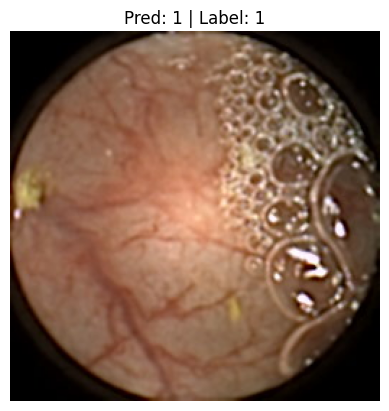

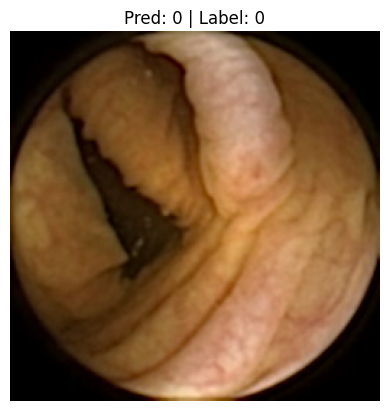

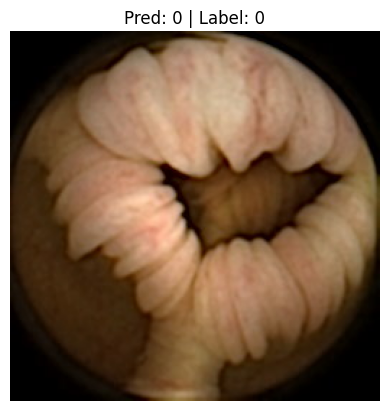

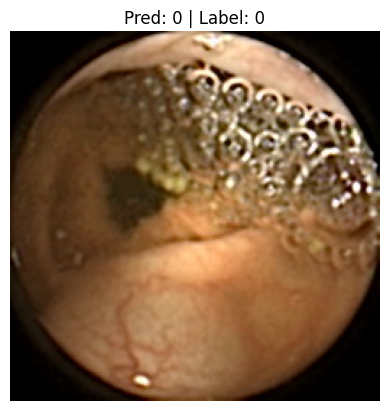

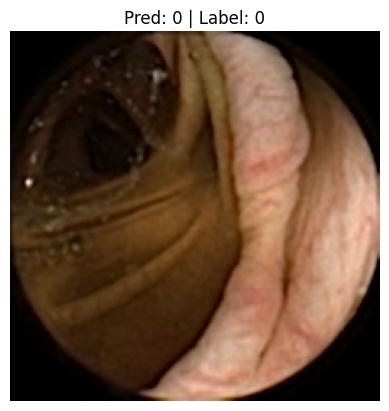

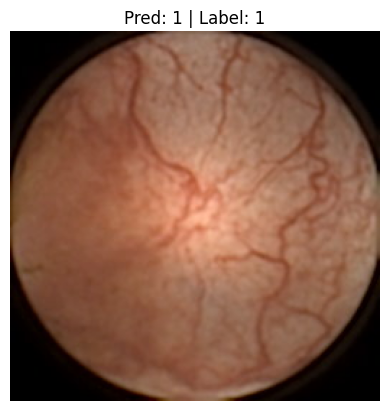

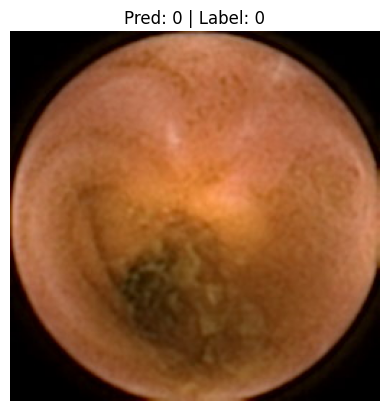

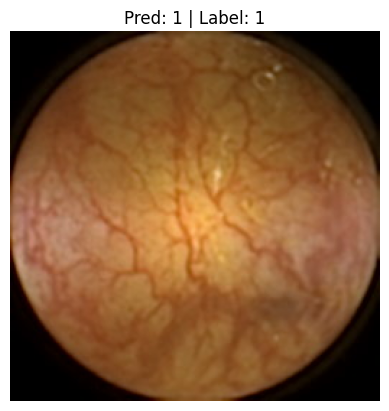

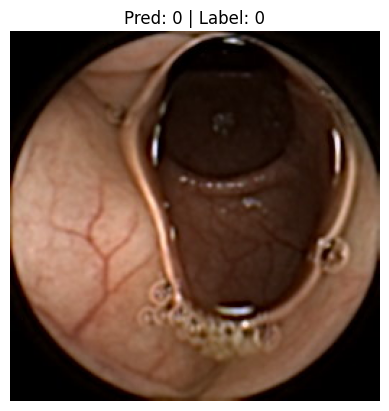

0.9823943661971831


In [3]:
# Load the model
model = RNet().to(device)
#model.load_state_dict(th.load("resnet18_not_pretrained.pt"))
model.load_state_dict(th.load("resnet18_not_pretrained_with_dropout.pt"))

# Test the model
model.eval()

# Test loop
total_images = 0
nr_acc = 0
for images, label in data_handler.te_loader:
    images = images.to(device)
    labels = label.to(device)
    
    # Forward pass
    outputs = model(images)
    
    # Predicted classes
    predicted = th.argmax(outputs, dim=1)
    
    # Accuracy calculation (vectorized)
    nr_acc += (predicted == labels).sum().item()  # Count correct predictions
    total_images += labels.size(0)  # Keep track of the total number of images
    
    
    # Original image
    plt.imshow(images[0].cpu().permute(1, 2, 0).numpy())
    plt.title(f"Pred: {"1" if predicted[0] else "0"} | Label: {labels[0]}")
    plt.axis('off')
    
    plt.show()

print(nr_acc/total_images)